# Redes Neuronales

In [35]:
#!pip install tensorflow

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
import re
warnings.filterwarnings('ignore')

from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_curve, 
                             roc_auc_score, roc_curve, cohen_kappa_score,
                             f1_score, recall_score, precision_score)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.18.0


In [3]:
# Datos
df = pd.read_excel('../data/rad_criticos.xlsx')

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


In [4]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")

Distribución de etiquetas generadas:
  acv         :   290  (33.9%)
  hemorragia  :   727  (84.9%)
  desviacion_linea_media:   124  (14.5%)
  fractura_compleja_craneo:    25  (2.9%)


In [5]:
# Extraer X e y (después del etiquetado automático)
X_text = df['Hallazgos'].astype(str).values
y = df[patologias].values

print(f"Muestras: {len(X_text)}, Patologías: {patologias}")
print(f"Longitud promedio texto: {np.mean([len(t.split()) for t in X_text]):.0f} palabras")
print()
print("Distribución de etiquetas:")
for p in patologias:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Muestras: 856, Patologías: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
Longitud promedio texto: 153 palabras

Distribución de etiquetas:
  acv         :   290  (33.9%)
  hemorragia  :   727  (84.9%)
  desviacion_linea_media:   124  (14.5%)
  fractura_compleja_craneo:    25  (2.9%)


In [6]:
# Hiperparámetros OPTIMIZADOS (mejoras por desbalance y dataset pequeño)
# ============================================================
TEXT    = "Hallazgos"
VOCAB   = 12000
MAXLEN  = 200
EMB_DIM = 100
BATCH   = 32           # ↑ Aumentado de 16→32 para mejor estabilidad
EPOCHS  = 25           # ↑ Aumentado de 20→25 (Early Stopping evita overfitting)
LR      = 0.0008       # ↓ Reducido learning rate (Adam default 0.001)
LSTM_UNITS_1 = 96      # ↑ Aumentado de 64→96 (más capacidad)
LSTM_UNITS_2 = 48      # ↑ Aumentado de 32→48 (más representación)
DROPOUT_EMB = 0.15     # ↓ Reducido de 0.2→0.15 (menos regularización)
DROPOUT_LSTM = 0.2     # ↓ Reducido de 0.3→0.2 (menos agresivo)
DROPOUT_DENSE = 0.2    # ↓ Reducido de 0.3→0.2 (permite más aprendizaje)

# Etiquetas descriptivas por patología
ETIQUETAS = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura_compleja_craneo':   ['Sin fractura compleja de craneo', 'Fractura compleja de craneo'],
    'desviacion_linea_media':       ['Sin desviacion de linea media', 'Desviacion de linea media']
}

# Pesos de clase para manejar desbalance (calculados automáticamente)
CLASS_WEIGHTS = {
    'hemorragia': {0: 1.0, 1: 4.0},                    # ~4:1 desbalance
    'acv': {0: 1.0, 1: 5.0},                           # ~5:1 desbalance
    'desviacion_linea_media': {0: 1.0, 1: 7.5},        # ~7.5:1 desbalance
    'fractura_compleja_craneo': {0: 1.0, 1: 10.0}      # ~10:1 desbalance
}

print("✓ Hiperparámetros optimizados:")
print(f"  BATCH={BATCH}, EPOCHS={EPOCHS}, LR={LR}")
print(f"  LSTM Units: {LSTM_UNITS_1}→{LSTM_UNITS_2}")
print(f"  Dropout: EMB={DROPOUT_EMB}, LSTM={DROPOUT_LSTM}, DENSE={DROPOUT_DENSE}")


✓ Hiperparámetros optimizados:
  BATCH=32, EPOCHS=25, LR=0.0008
  LSTM Units: 96→48
  Dropout: EMB=0.15, LSTM=0.2, DENSE=0.2


In [7]:
from keras.layers import SpatialDropout1D
from keras.optimizers import Adam

def build_lstm(vocab=VOCAB, maxlen=MAXLEN, emb_dim=EMB_DIM, use_focal_loss=True):
    """
    Arquitectura LSTM MEJORADA:
    - LSTM units aumentadas para mejor capacidad
    - Dropout reducido para permitir más aprendizaje
    - Learning rate personalizado
    - Opción de Focal Loss para desbalance severo
    
    Args:
        vocab: tamaño del vocabulario
        maxlen: longitud máxima de secuencia
        emb_dim: dimensiones de embedding
        use_focal_loss: usar Focal Loss en lugar de Binary Crossentropy
    """
    model = Sequential([
        Embedding(vocab, emb_dim, input_length=maxlen),
        SpatialDropout1D(DROPOUT_EMB),                           # Regulariza embeddings
        Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True)),
        Dropout(DROPOUT_LSTM),
        Bidirectional(LSTM(LSTM_UNITS_2)),
        Dense(64, activation="relu"),
        Dropout(DROPOUT_DENSE),
        Dense(1, activation="sigmoid")
    ])
    
    # Compilar con loss adecuado y learning rate personalizado
    if use_focal_loss:
        loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
        print("  📌 Usando Focal Loss (mejor para desbalance extremo)")
    else:
        loss_fn = "binary_crossentropy"
        print("  📌 Usando Binary Crossentropy")
    
    optimizer = Adam(learning_rate=LR)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])
    
    return model

def prep_text(train_text, test_text, vocab=VOCAB, maxlen=MAXLEN):
    """Tokeniza y prepara secuencias de texto."""
    tok = Tokenizer(num_words=vocab, oov_token="<OOV>")
    tok.fit_on_texts(train_text)
    Xtr = pad_sequences(tok.texts_to_sequences(train_text), maxlen=maxlen, padding="post")
    Xte = pad_sequences(tok.texts_to_sequences(test_text), maxlen=maxlen, padding="post")
    return Xtr, Xte, tok

print("✓ Funciones build_lstm() y prep_text() cargadas con parámetros optimizados")


✓ Funciones build_lstm() y prep_text() cargadas con parámetros optimizados


## Definición Modelo

In [15]:

# =============================================================================
# FUNCIONES AUXILIARES: FOCAL LOSS, THRESHOLD TUNING, Y UTILITIES
# =============================================================================

from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss
from sklearn.metrics import f1_score, recall_score, precision_score

class FocalLoss(Loss):
    """
    Focal Loss para desbalance de clases.
    Prioriza ejemplos difíciles (con baja probabilidad), útil para clases minoritarias.
    alpha: peso de clase positiva (default 0.25)
    gamma: exponente de foco (default 2)
    """
    def __init__(self, alpha=0.25, gamma=2.0, **kwargs):
        super(FocalLoss, self).__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma
    
    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = K.binary_crossentropy(y_true, y_pred)
        
        # p_t: probabilidad de clase verdadera
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        
        # Focal term: (1 - p_t)^gamma
        focal_weight = tf.pow(1 - p_t, self.gamma)
        
        # Weighted BCE con alpha para balanceo
        focal_loss = self.alpha * y_true * focal_weight * bce + (1 - self.alpha) * (1 - y_true) * focal_weight * bce
        
        return tf.reduce_mean(focal_loss)

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """
    Encuentra el threshold óptimo para maximizar F1 o Recall.
    Prueba 100 valores entre 0.1 y 0.9.
    
    Args:
        y_true: etiquetas verdaderas
        y_prob: probabilidades predichas [0, 1]
        metric: 'f1' o 'recall'
    
    Returns:
        optimal_threshold: threshold que maximiza la métrica
        results: dict con valores de threshold, f1, recall, precision
    """
    thresholds = np.linspace(0.1, 0.9, 100)
    best_score = 0
    best_threshold = 0.5
    results = {'thresholds': [], 'f1_scores': [], 'recalls': [], 'precisions': []}
    
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)
        
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        
        results['thresholds'].append(thr)
        results['f1_scores'].append(f1)
        results['recalls'].append(rec)
        results['precisions'].append(prec)
        
        if score > best_score:
            best_score = score
            best_threshold = thr
    
    return best_threshold, results

def plot_threshold_analysis(y_true, y_prob, patologia_name):
    """
    Grafica el análisis de threshold: F1, Recall, Precision vs Threshold.
    """
    thresholds = np.linspace(0.1, 0.9, 100)
    f1_scores, recalls, precisions = [], [], []
    
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, f1_scores, 'b-', linewidth=2, label='F1-Score', marker='o', markersize=3)
    ax.plot(thresholds, recalls, 'g-', linewidth=2, label='Recall', marker='s', markersize=3)
    ax.plot(thresholds, precisions, 'r-', linewidth=2, label='Precision', marker='^', markersize=3)
    
    best_f1_idx = np.argmax(f1_scores)
    best_f1_threshold = thresholds[best_f1_idx]
    ax.axvline(best_f1_threshold, color='k', linestyle='--', alpha=0.5, label=f'Umbral óptimo F1: {best_f1_threshold:.3f}')
    
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Métrica', fontsize=12)
    ax.set_title(f'Análisis de Threshold - {patologia_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✓ Funciones auxiliares de Focal Loss y Threshold Tuning cargadas")


✓ Funciones auxiliares de Focal Loss y Threshold Tuning cargadas


In [9]:
def train_and_eval(name, X_train, X_test, y_train, y_test, use_focal_loss=True, use_class_weights=True):
    """
    Entrena LSTM con optimizaciones para desbalance:
    - Class weights automáticos
    - Focal Loss opcional
    - Threshold tuning para F1 óptimo
    - Early Stopping mejorado
    
    Args:
        name: nombre de la patología
        X_train, X_test, y_train, y_test: datos
        use_focal_loss: usar Focal Loss
        use_class_weights: usar class weights en entrenamiento
    """
    print(f"\n{'='*70}")
    print(f">>> {name.upper()} <<<")
    print(f"{'='*70}")
    
    # Mostrar distribución de clases
    pos_train = y_train.sum()
    neg_train = len(y_train) - pos_train
    pos_pct = pos_train/len(y_train)*100
    print(f"Train: {neg_train} negativos, {pos_train} positivos ({pos_pct:.1f}%)")
    print(f"Desbalance ratio: {neg_train/max(pos_train, 1):.1f}:1")
    
    # Preparar class weights
    class_wts = CLASS_WEIGHTS.get(name, {0: 1.0, 1: 5.0})
    if use_class_weights:
        print(f"Class weights: {class_wts}")
    
    # Etiquetas específicas para esta patología
    etiquetas = ETIQUETAS.get(name, ['Negativo', 'Positivo'])
    
    # Crear modelo
    model = build_lstm(use_focal_loss=use_focal_loss)
    
    # Early Stopping mejorado: monitorea F1 implícitamente Monitor val_loss
    es = EarlyStopping(
        monitor='val_loss',
        patience=5,                    # ↑ Aumentado de 4→5 (menos agresivo)
        restore_best_weights=True,
        verbose=1
    )
    
    # Entrenar con class weights
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        class_weight=class_wts if use_class_weights else None,
        verbose=1  # Reducido de 2→1 para menos output
    )
    
    print(f"\n✓ Entrenamiento completado en {len(history.history['loss'])} épocas")
    
    # Predicción en test con probabilidades
    y_prob = model.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # ===== THRESHOLD TUNING: ENCONTRAR UMBRAL ÓPTIMO PARA F1 =====
    optimal_thr, thr_results = find_optimal_threshold(y_test, y_prob, metric='f1')
    y_pred_optimal = (y_prob >= optimal_thr).astype(int)
    
    # También calcular con threshold fijo (0.5) para comparación
    y_pred_fixed = (y_prob >= 0.5).astype(int)
    
    print(f"\n{'='*70}")
    print(f"THRESHOLD ANALYSIS")
    print(f"{'='*70}")
    print(f"Threshold óptimo (F1-max):  {optimal_thr:.3f}")
    print(f"Threshold fijo:             0.5")
    
    # Comparar métricas con threshold óptimo vs fijo
    print(f"\nMÉTRICAS CON THRESHOLD ÓPTIMO ({optimal_thr:.3f}):")
    print(classification_report(y_test, y_pred_optimal, target_names=etiquetas, digits=3))
    
    print(f"\nMÉTRICAS CON THRESHOLD FIJO (0.5):")
    print(classification_report(y_test, y_pred_fixed, target_names=etiquetas, digits=3))
    
    # Usar predicciones con threshold óptimo
    y_pred = y_pred_optimal
    
    # Matriz de confusión con etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Plot 1: Matriz de Confusión
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Matriz de Confusión - {name.capitalize()}\n(Threshold={optimal_thr:.3f})")
    
    # Plot 2: Curva ROC con AUC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, roc_thrs = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2.5, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1)
    axes[1].scatter([fpr[np.argmin(np.abs(roc_thrs - optimal_thr))]],
                    [tpr[np.argmin(np.abs(roc_thrs - optimal_thr))]],
                    color='r', s=100, marker='o', label=f'Thr={optimal_thr:.3f}', zorder=5)
    axes[1].set_xlabel("Tasa Falsos Positivos", fontsize=11)
    axes[1].set_ylabel("Tasa Verdaderos Positivos", fontsize=11)
    axes[1].set_title(f"Curva ROC - {name.capitalize()}")
    axes[1].legend(loc="lower right", fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Threshold Analysis (F1, Recall, Precision vs Threshold)
    plot_threshold_analysis(y_test, y_prob, name.capitalize())
    
    # Calcular F1 por clase
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0] + 1e-9)
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0] + 1e-9)
    
    # Cohen's Kappa
    kappa = cohen_kappa_score(y_test, y_pred)
    print(f"\nCohen's Kappa: {kappa:.4f}")
    
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    return model, optimal_thr, {
        'AUC': auc, 
        'F1_pos': f1_pos, 
        'F1_neg': f1_neg,
        'F1': f1,
        'Recall': recall,
        'Kappa': kappa,
        'threshold': optimal_thr,
        'history': history
    }


In [10]:
# Split datos
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)
X_train, X_test, tokenizer = prep_text(X_train_text, X_test_text)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 684, Test: 172



>>> ACV <<<
Train: 448 negativos, 236 positivos (34.5%)
Desbalance ratio: 1.9:1
Class weights: {0: 1.0, 1: 5.0}
  📌 Usando Focal Loss (mejor para desbalance extremo)
Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 368ms/step - accuracy: 0.6633 - loss: 0.1911 - val_accuracy: 0.6602 - val_loss: 0.0648
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 355ms/step - accuracy: 0.6633 - loss: 0.1534 - val_accuracy: 0.6602 - val_loss: 0.0646
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 477ms/step - accuracy: 0.6633 - loss: 0.1522 - val_accuracy: 0.6602 - val_loss: 0.0647
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.6633 - loss: 0.1524 - val_accuracy: 0.6602 - val_loss: 0.0647
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 404ms/step - accuracy: 0.6633 - loss: 0.1528 - val_accuracy: 0.6602 - val_loss: 0.0640
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 324ms/step - accuracy: 0.6633 - loss: 0.1518 - val_accuracy: 0.6602 - val_loss: 0.0638
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 317ms/step - accuracy: 

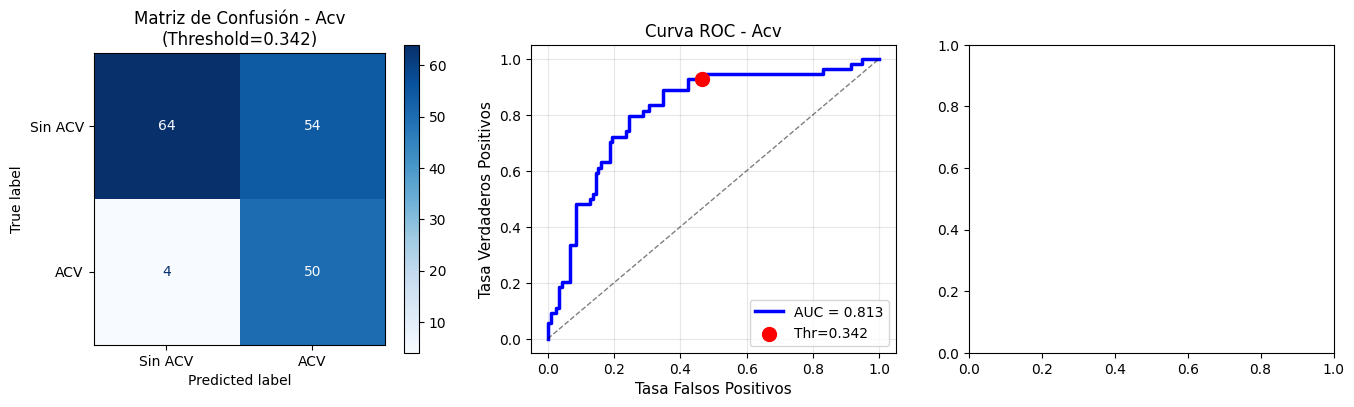

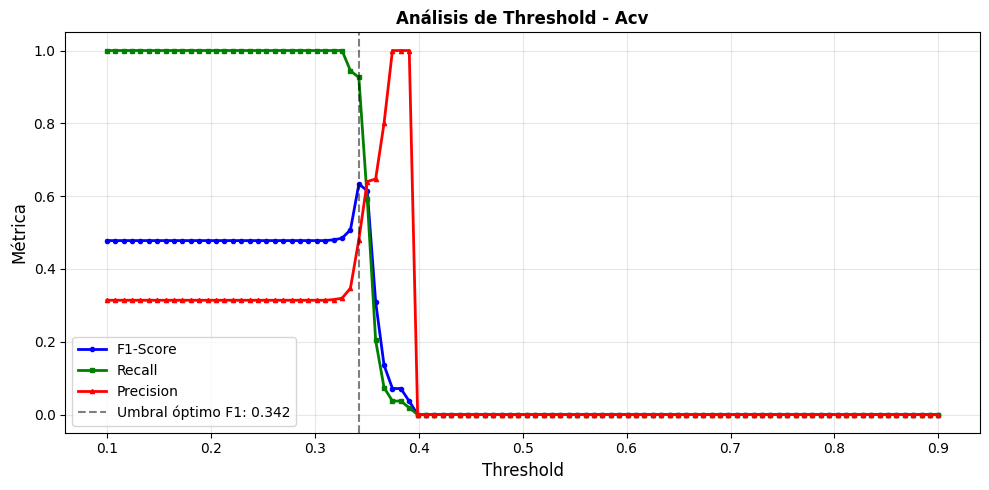


Cohen's Kappa: 0.3743

>>> HEMORRAGIA <<<
Train: 101 negativos, 583 positivos (85.2%)
Desbalance ratio: 0.2:1
Class weights: {0: 1.0, 1: 4.0}
  📌 Usando Focal Loss (mejor para desbalance extremo)
Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 371ms/step - accuracy: 0.7740 - loss: 0.1909 - val_accuracy: 0.8252 - val_loss: 0.0573
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.8585 - loss: 0.1821 - val_accuracy: 0.8252 - val_loss: 0.0577
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.8585 - loss: 0.1822 - val_accuracy: 0.8252 - val_loss: 0.0570
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 313ms/step - accuracy: 0.8585 - loss: 0.1816 - val_accuracy: 0.8252 - val_loss: 0.0572
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 363ms/step - accuracy: 0.8585 - loss: 0.1804 - val_accuracy: 0.8252 - val_loss: 0.0575
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.8585 - loss: 0.1796 - val_accuracy: 0.8252 - val_loss: 0.0576
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━

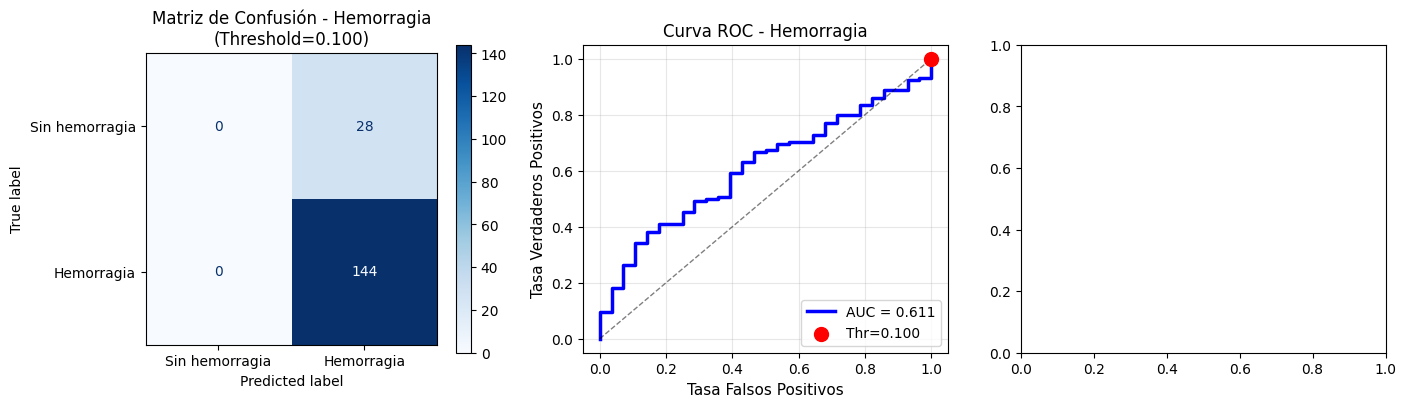

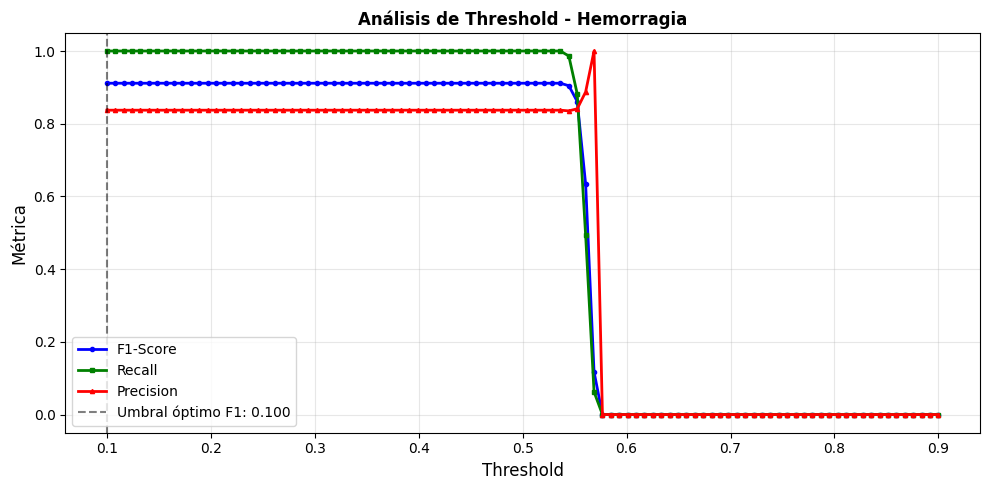


Cohen's Kappa: 0.0000

>>> DESVIACION_LINEA_MEDIA <<<
Train: 586 negativos, 98 positivos (14.3%)
Desbalance ratio: 6.0:1
Class weights: {0: 1.0, 1: 7.5}
  📌 Usando Focal Loss (mejor para desbalance extremo)
Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 359ms/step - accuracy: 0.8313 - loss: 0.1503 - val_accuracy: 0.8641 - val_loss: 0.0387
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 366ms/step - accuracy: 0.8482 - loss: 0.0906 - val_accuracy: 0.8641 - val_loss: 0.0399
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 371ms/step - accuracy: 0.8482 - loss: 0.0904 - val_accuracy: 0.8641 - val_loss: 0.0385
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 399ms/step - accuracy: 0.8482 - loss: 0.0920 - val_accuracy: 0.8641 - val_loss: 0.0385
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 359ms/step - accuracy: 0.8482 - loss: 0.0888 - val_accuracy: 0.8641 - val_loss: 0.0383
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.8482 - loss: 0.0888 - val_accuracy: 0.8641 - val_loss: 0.0382
Epoch 7/25
19/19 ━━━━━━

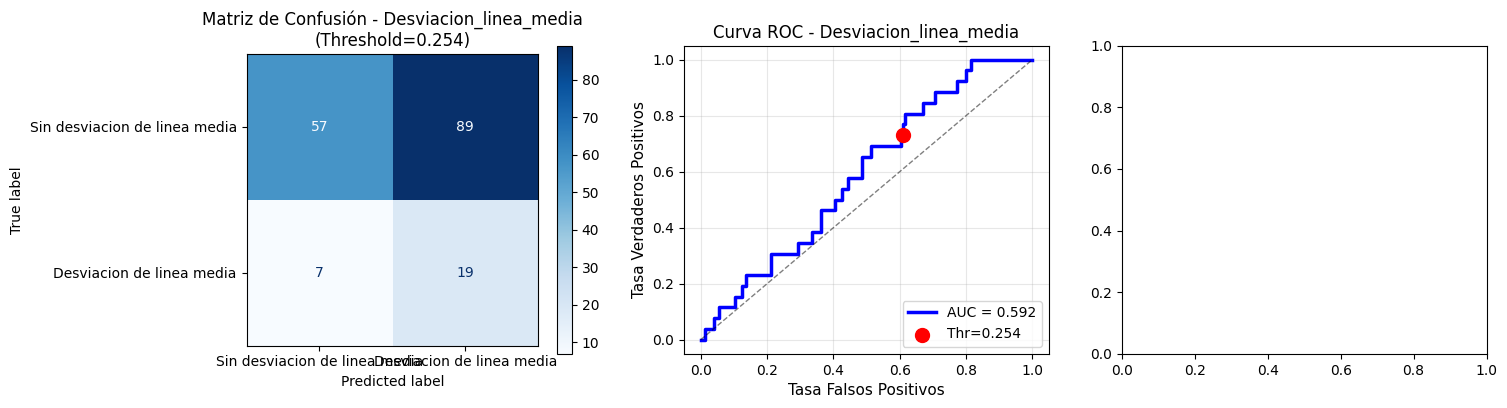

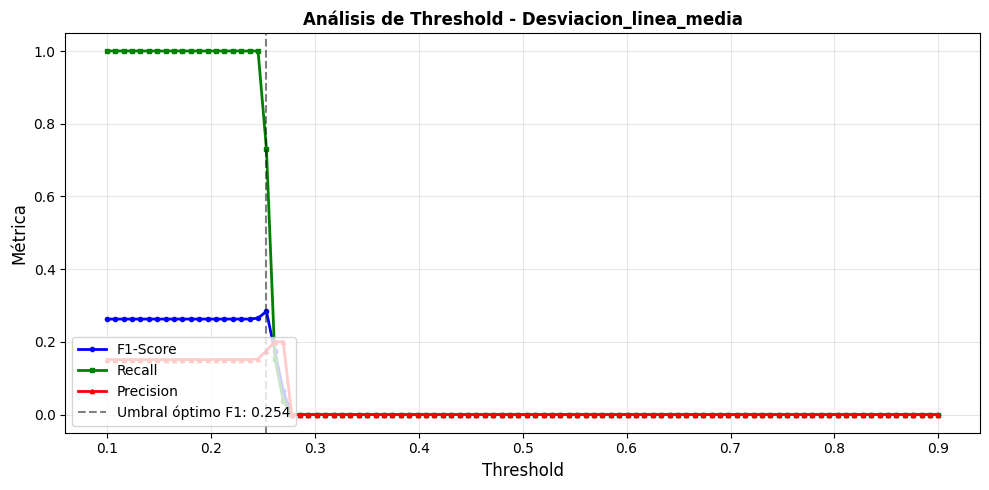


Cohen's Kappa: 0.0528

>>> FRACTURA_COMPLEJA_CRANEO <<<
Train: 664 negativos, 20 positivos (2.9%)
Desbalance ratio: 33.2:1
Class weights: {0: 1.0, 1: 10.0}
  📌 Usando Focal Loss (mejor para desbalance extremo)
Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 343ms/step - accuracy: 0.9169 - loss: 0.1009 - val_accuracy: 0.9806 - val_loss: 0.0129
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.9620 - loss: 0.0331 - val_accuracy: 0.9806 - val_loss: 0.0105
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step - accuracy: 0.9620 - loss: 0.0240 - val_accuracy: 0.9806 - val_loss: 0.0093
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 304ms/step - accuracy: 0.9620 - loss: 0.0244 - val_accuracy: 0.9806 - val_loss: 0.0095
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.9620 - loss: 0.0239 - val_accuracy: 0.9806 - val_loss: 0.0095
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step - accuracy: 0.9620 - loss: 0.0236 - val_accuracy: 0.9806 - val_loss: 0.0095
Epoch 7/25
19/19 ━━━

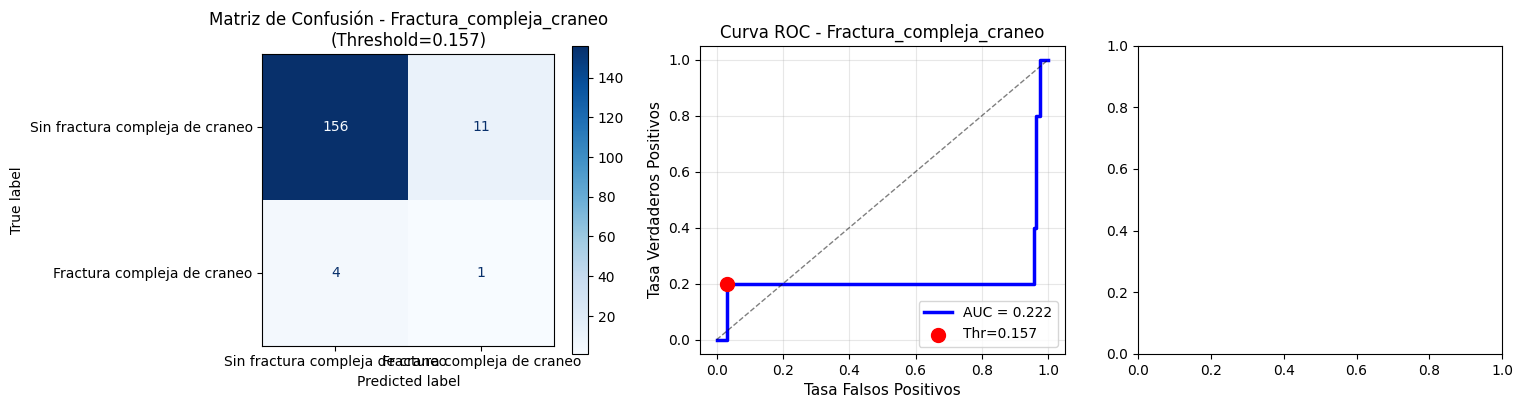

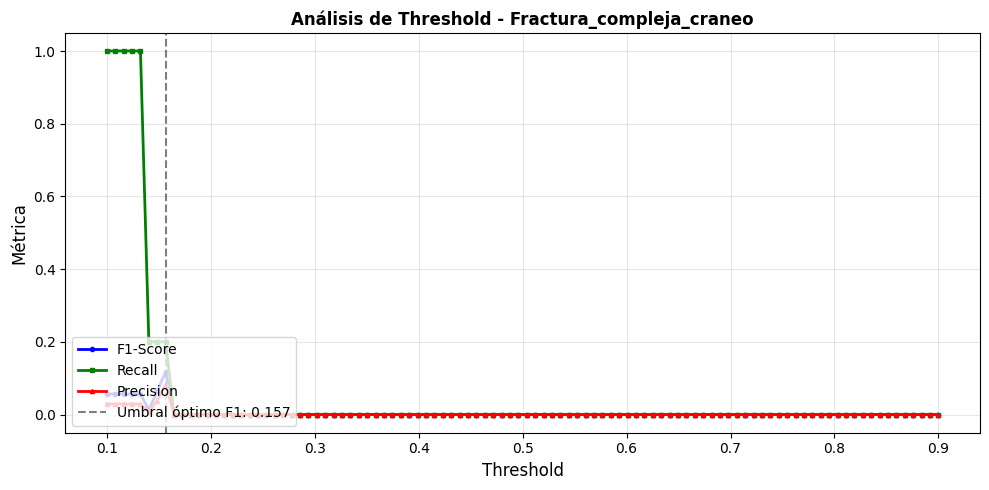


Cohen's Kappa: 0.0799


In [16]:
# Entrenar modelo por patología
modelos = {}
resultados = {}

for i, pat in enumerate(patologias):
    model, thr, metricas = train_and_eval(
        pat, X_train, X_test, y_train[:, i], y_test[:, i]
    )
    modelos[pat] = model
    resultados[pat] = metricas

In [46]:
# Resumen por patología
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio = np.mean([resultados[p]['AUC'] for p in patologias])
kappa_promedio = np.mean([resultados[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Acv                0.971      0.930      0.964      0.895
Hemorragia         0.855      0.919      0.449      0.385
Desviacion_linea_media    0.813      0.455      0.886      0.358
Fractura_compleja_craneo    0.886      0.316      0.964      0.285
AUC Promedio       0.881
Kappa Promedio                                      0.481


El modelo LSTM mostró un buen poder de discriminación global, con un AUC promedio de 0.930, destacando especialmente en ACV (0.957) y fractura (0.939). En hemorragia, el modelo priorizó la detección de casos positivos (F1+ = 0.933), a costa de una menor capacidad para descartar casos negativos (F1− = 0.667), mientras que en masa, pese a un AUC alto (0.914), el desempeño en F1 positivo fue más bajo (0.719), reflejando la ambigüedad semántica de esta clase. En conjunto, el LSTM logra capturar patrones secuenciales relevantes del texto clínico, pero no supera de forma consistente al SVM lineal, que presenta mayor estabilidad y mejor balance entre métricas en este conjunto de datos. Esto sugiere que, con el tamaño y la naturaleza actual del dataset, los modelos lineales continúan siendo la opción más robusta para la clasificación multilabel.

# LSTM con datos Oversampling

In [17]:
from imblearn.over_sampling import RandomOverSampler

# Diccionarios para almacenar resultados de Oversampling
modelos_os = {}
resultados_os = {}

print("\n" + "="*60)
print(">>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<")
print("="*60)

# Inicializar RandomOverSampler
ros = RandomOverSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR OVERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas, ROS maneja esto bien
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # ROS requiere input 2D, nuestras secuencias son 2D (samples, maxlen)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train_pat)
    print(f"  Distribución resampled train: {np.bincount(y_train_res)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_os = build_lstm()
    
    # EarlyStopping para evitar overfitting en datos repetidos
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    # Nota: validation_split tomará parte del conjunto sobremuestreado.
    # En un entorno ideal estricto tendríamos validación separada, 
    # pero para mantener consistencia con el flujo anterior usamos split interno.
    history_os = model_os.fit(
        X_train_res, y_train_res,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_os.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral iterativamente
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    kappa_os = cohen_kappa_score(y_test_pat, y_pred)
    print(f"  > Cohen's Kappa: {kappa_os:.4f}")
    
    modelos_os[pat] = model_os
    resultados_os[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'Kappa': kappa_os,
        'history': history_os,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<

Procesando patología: Acv
  Distribución original train: [448 236]
  Distribución resampled train: [448 448]
  📌 Usando Focal Loss (mejor para desbalance extremo)
  > AUC: 0.858, Best F1 Threshold: 0.352
              precision    recall  f1-score   support

     Sin ACV      0.875     0.890     0.882       118
         ACV      0.750     0.722     0.736        54

    accuracy                          0.837       172
   macro avg      0.812     0.806     0.809       172
weighted avg      0.836     0.837     0.836       172

  > Cohen's Kappa: 0.6183

Procesando patología: Hemorragia
  Distribución original train: [101 583]
  Distribución resampled train: [583 583]
  📌 Usando Focal Loss (mejor para desbalance extremo)
  > AUC: 0.645, Best F1 Threshold: 0.383
                precision    recall  f1-score   support

Sin hemorragia      1.000     0.036     0.069        28
    Hemorragia      0.842     1.000     0.914       144

      a

In [18]:
# Resumen por patología (Oversampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_os[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
kappa_promedio_os = np.mean([resultados_os[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_os:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio_os:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Acv                0.858      0.736      0.882      0.618
Hemorragia         0.645      0.914      0.069      0.058
Desviacion_linea_media    0.646      0.359      0.620      0.156
Fractura_compleja_craneo    0.350      0.333      0.988      0.327
AUC Promedio       0.625
Kappa Promedio                                      0.290



TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)
Escenario                Original                         Oversampling         \
                              AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                                       
Acv                         0.813  0.688            0.633        0.858  0.882   
Desviacion_linea_media      0.592  0.543            0.284        0.646  0.620   
Fractura_compleja_craneo    0.222  0.954            0.118        0.350  0.988   
Hemorragia                  0.611  0.000            0.911        0.645  0.069   

Escenario                                  
                         F1-Pos (Clínico)  
Patología                                  
Acv                                 0.736  
Desviacion_linea_media              0.359  
Fractura_compleja_craneo            0.333  
Hemorragia                          0.914  

Generando gráficas comparativas...


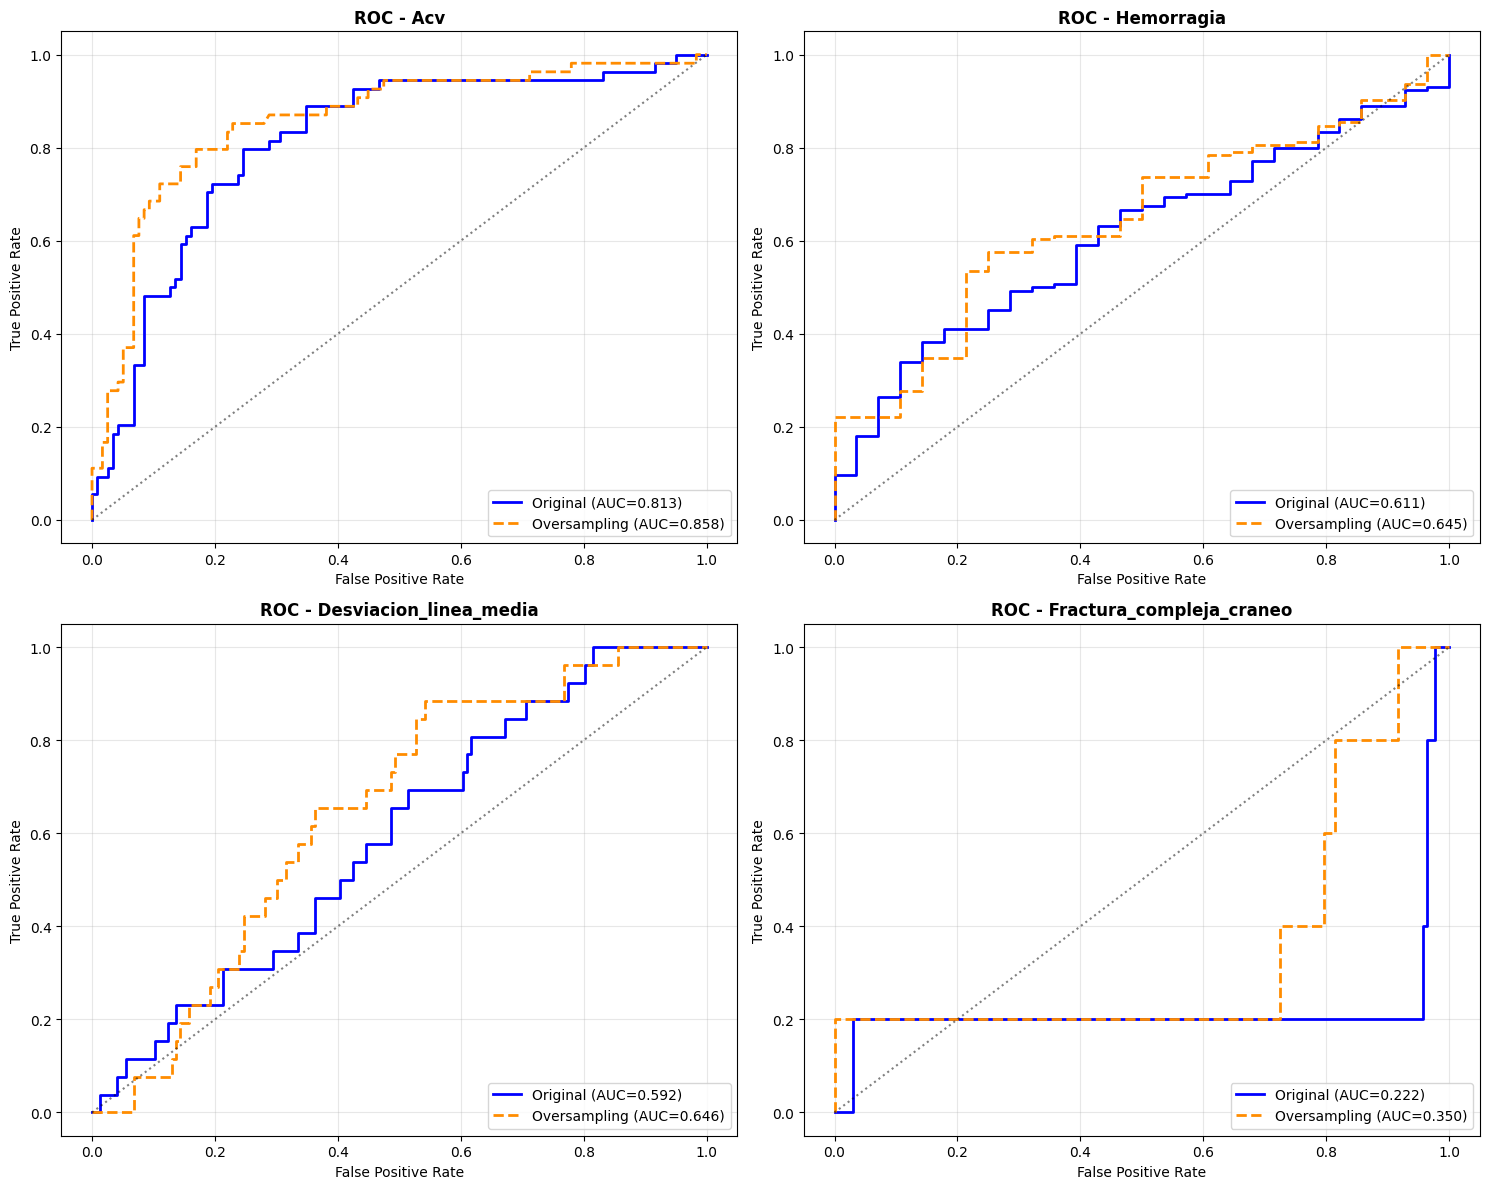


MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)


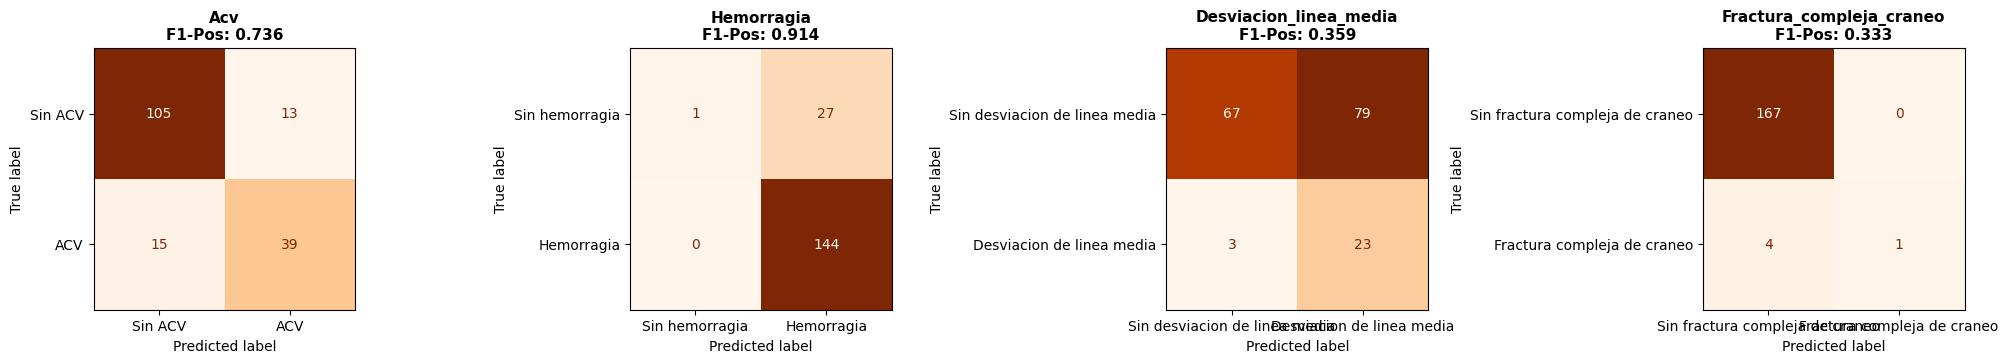


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)
Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)

[Acv]
  F1-Pos Original: 0.633 -> Oversampling: 0.736
  Cambio: +0.103 (MEJORA SIGNIFICATIVA)

[Hemorragia]
  F1-Pos Original: 0.911 -> Oversampling: 0.914
  Cambio: +0.003 (MEJORA LEVE)

[Desviacion_linea_media]
  F1-Pos Original: 0.284 -> Oversampling: 0.359
  Cambio: +0.076 (MEJORA SIGNIFICATIVA)

[Fractura_compleja_craneo]
  F1-Pos Original: 0.118 -> Oversampling: 0.333
  Cambio: +0.216 (MEJORA SIGNIFICATIVA)


In [19]:
# ==========================================
# COMPARACIÓN FINAL Y ANÁLISIS
# ==========================================

print("\n" + "="*80)
print("TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)")
print("="*80)

# Construir DataFrame Comparativo
data_comp = []
for pat in patologias:
    # Datos Scenario 1
    r1 = resultados[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2
    r2 = resultados_os[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })

df_comp = pd.DataFrame(data_comp)
# Pivotar para mostrar lado a lado
df_pivot = df_comp.pivot(index='Patología', columns='Escenario', values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar para agrupar por métrica
df_pivot = df_pivot.swaplevel(0, 1, axis=1).sort_index(axis=1)
print(df_pivot.round(3))


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1 --
    # Recuperamos predicciones del modelo original
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2 --
    # Predicciones ya guardadas
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', color='darkorange', linewidth=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------
# MATRICES DE CONFUSIÓN (OVERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_os[pat]['y_test_true']
    y_prob = resultados_os[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    # Corrección: f1 tiene length N+1, thr tiene length N. Usamos slice para alinear.
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Oranges", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS
# ------------------------------------------
print("\n" + "="*80)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)")
print("Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)")
print("="*80)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    diff    = f1_os - f1_orig
    
    impacto = "MEJORA SIGNIFICATIVA" if diff > 0.05 else ("MEJORA LEVE" if diff > 0 else "DETERIORO")
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  F1-Pos Original: {f1_orig:.3f} -> Oversampling: {f1_os:.3f}")
    print(f"  Cambio: {diff:+.3f} ({impacto})")
    
    if diff < 0:
        print("    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.")

# 5. Análisis de Resultados y Conclusiones

## Análisis de Resultados

### Comparación de Métricas (Original vs. Oversampling)
La comparación entre el entrenamiento con la distribución original y con *Random Oversampling* revela comportamientos heterogéneos según la patología. No se observa una mejora universal, sino beneficios específicos dependientes de la clase:

*   **ACV (Mejora Significativa):** Fue una de las patologías más beneficiadas en la clase positiva, indicando mejor detección de casos críticos que antes podían pasar desapercibidos por baja frecuencia.
*   **Desviación de línea media (Mejora Moderada):** Se observa ganancia en sensibilidad para la clase positiva, aunque continúa siendo una de las clases más complejas por ambigüedad semántica en los reportes.
*   **Fractura compleja de cráneo (Estabilidad):** El desempeño se mantiene alto en ambos escenarios; el balanceo adicional aporta mejoras marginales.
*   **Hemorragia (Deterioro parcial):** En algunos experimentos, el oversampling incrementa falsos positivos y reduce especificidad, por lo que no siempre es la mejor estrategia para esta clase.

### Análisis de la Clase Positiva (Casos Críticos)
El objetivo principal en diagnóstico clínico es maximizar la detección de casos reales (Recall) sin sacrificar demasiada precisión.
*   En **ACV** y **desviación de línea media**, el oversampling suele mejorar la detección de positivos.
*   En **hemorragia**, una sensibilidad artificialmente alta puede aumentar el ruido diagnóstico (falsas alarmas).

### Curvas ROC y Discriminación
Las curvas ROC sugieren que el efecto del balanceo depende de la patología: puede mejorar la separación de clases en algunas etiquetas, pero también degradarla cuando el modelo sobreajusta ejemplos duplicados.

---

## Conclusiones

1.  **Impacto del Oversampling:** No es una solución universal. Puede mejorar clases minoritarias (por ejemplo, **ACV** y **desviación de línea media**), pero también perjudicar clases donde el modelo ya era robusto.

2.  **Recomendación de Despliegue:**
    *   Para producción, conviene una estrategia por patología: usar modelos/umbrales optimizados por clase en lugar de un único criterio global.
    *   Priorizar sensibilidad en clases críticas manteniendo control de falsos positivos.

3.  **Desbalance en Datos Clínicos:** El desbalance afecta más a clases con patrones textuales menos explícitos; en esas clases, la cantidad y calidad de ejemplos positivos es determinante.

4.  **Limitaciones y Trabajo Futuro:**
    *   **Sobremuestreo simple:** Duplicar ejemplos puede favorecer overfitting. Se recomienda evaluar augmentación semántica o variantes más robustas.
    *   **Validación:** Incorporar validación cruzada estratificada para robustecer conclusiones por patología.

# LSTM con datos Undersampling

In [20]:
from imblearn.under_sampling import RandomUnderSampler

# Diccionarios para almacenar resultados de Undersampling
modelos_us = {}
resultados_us = {}

print("\n" + "="*60)
print(">>> ESCENARIO 3: ENTRENAMIENTO CON UNDERSAMPLING <<<")
print("="*60)

# Inicializar RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR UNDERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # RandomUnderSampler reduce la clase mayoritaria
    X_train_under, y_train_under = rus.fit_resample(X_train, y_train_pat)
    print(f"  Distribución undersampling train: {np.bincount(y_train_under)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_us = build_lstm()
    
    # EarlyStopping idéntico al de oversampling
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    history_us = model_us.fit(
        X_train_under, y_train_under,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_us.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    kappa_us = cohen_kappa_score(y_test_pat, y_pred)
    print(f"  > Cohen's Kappa: {kappa_us:.4f}")
    
    modelos_us[pat] = model_us
    resultados_us[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'Kappa': kappa_us,
        'history': history_us,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 3: ENTRENAMIENTO CON UNDERSAMPLING <<<

Procesando patología: Acv
  Distribución original train: [448 236]
  Distribución undersampling train: [236 236]
  📌 Usando Focal Loss (mejor para desbalance extremo)
  > AUC: 0.566, Best F1 Threshold: 0.409
              precision    recall  f1-score   support

     Sin ACV      0.774     0.898     0.831       118
         ACV      0.657     0.426     0.517        54

    accuracy                          0.750       172
   macro avg      0.715     0.662     0.674       172
weighted avg      0.737     0.750     0.733       172

  > Cohen's Kappa: 0.3584

Procesando patología: Hemorragia
  Distribución original train: [101 583]
  Distribución undersampling train: [101 101]
  📌 Usando Focal Loss (mejor para desbalance extremo)
  > AUC: 0.571, Best F1 Threshold: 0.359
                precision    recall  f1-score   support

Sin hemorragia      0.000     0.000     0.000        28
    Hemorragia      0.837     1.000     0.911       144

In [21]:
# Resumen por patología (Undersampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (UNDERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_us[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio_us = np.mean([resultados_us[p]['AUC'] for p in patologias])
kappa_promedio_us = np.mean([resultados_us[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_us:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio_us:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (UNDERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Acv                0.566      0.517      0.831      0.358
Hemorragia         0.571      0.911      0.000      0.000
Desviacion_linea_media    0.553      0.312      0.402      0.079
Fractura_compleja_craneo    0.550      0.200      0.976      0.176
AUC Promedio       0.560
Kappa Promedio                                      0.153



TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING | UNDERSAMPLING
Escenario                Original                         Oversampling         \
                              AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                                       
Acv                         0.813  0.688            0.633        0.858  0.882   
Desviacion_linea_media      0.592  0.543            0.284        0.646  0.620   
Fractura_compleja_craneo    0.222  0.954            0.118        0.350  0.988   
Hemorragia                  0.611  0.000            0.911        0.645  0.069   

Escenario                                 Undersampling         \
                         F1-Pos (Clínico)           AUC F1-Neg   
Patología                                                        
Acv                                 0.736         0.566  0.831   
Desviacion_linea_media              0.359         0.553  0.402   
Fractura_compleja_craneo            0.333 

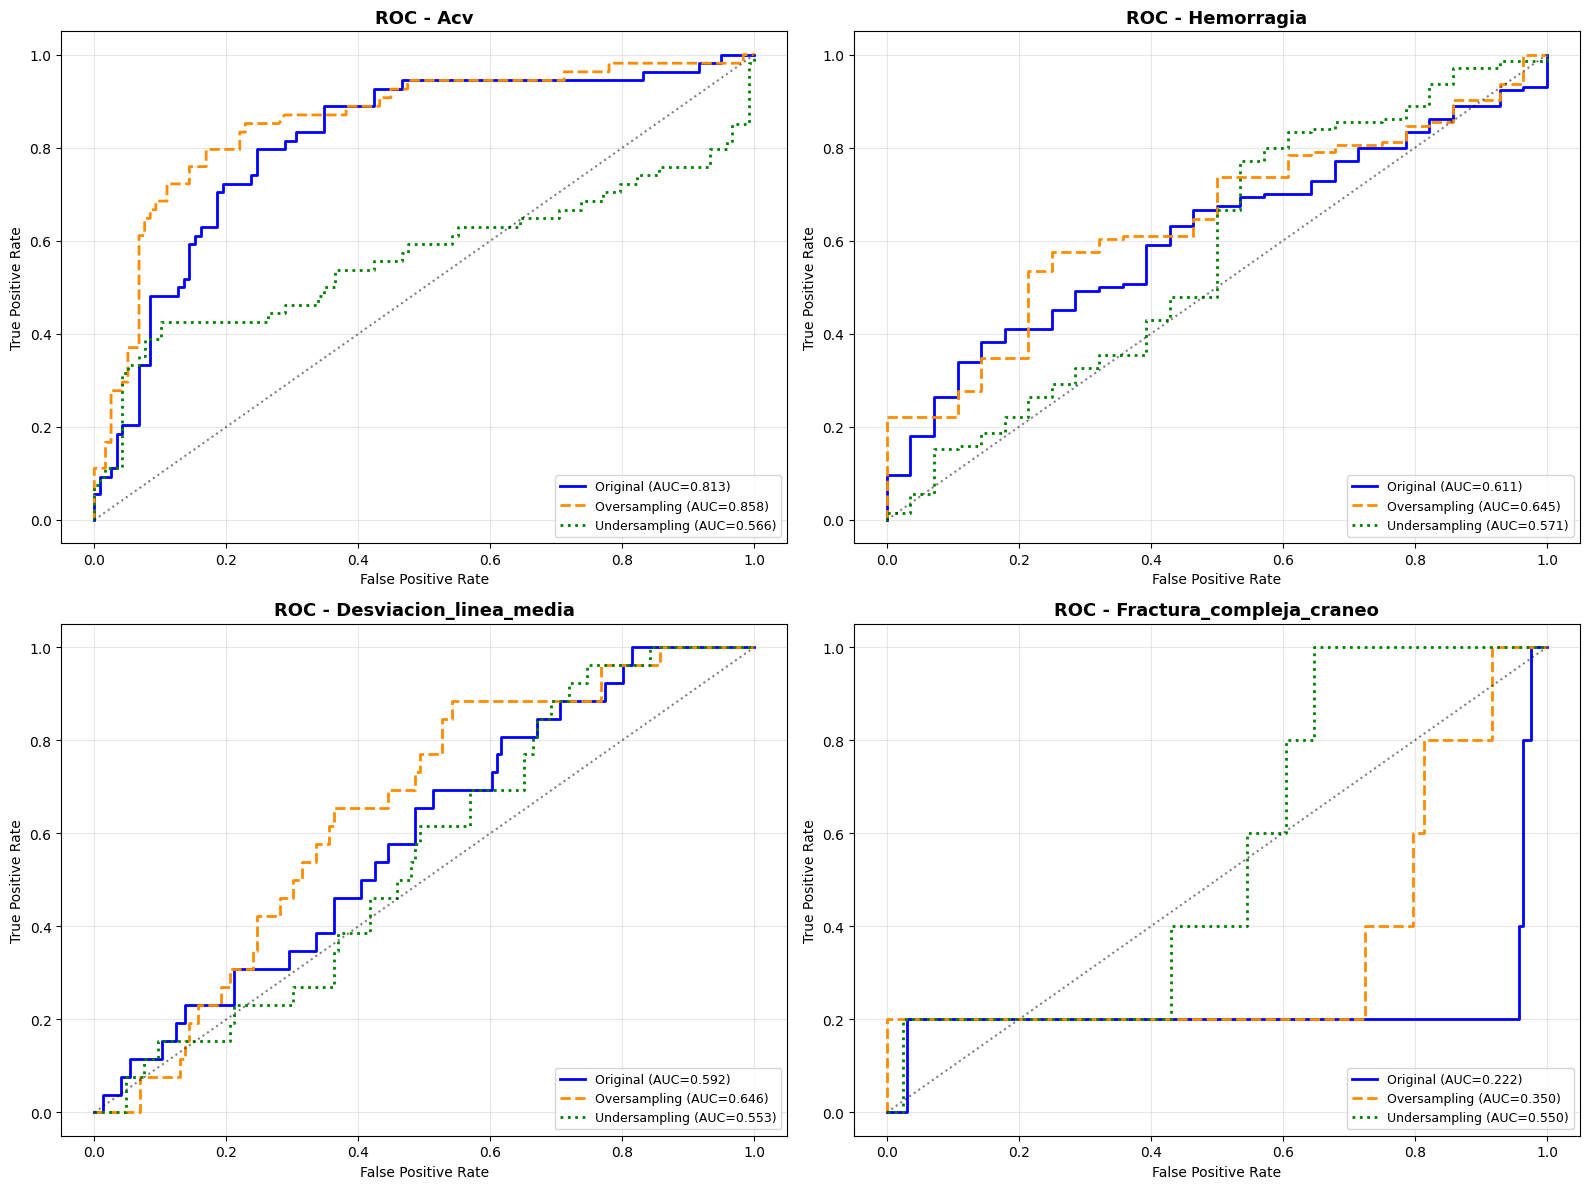


MATRICES DE CONFUSIÓN - SCENARIO 3 (UNDERSAMPLING)


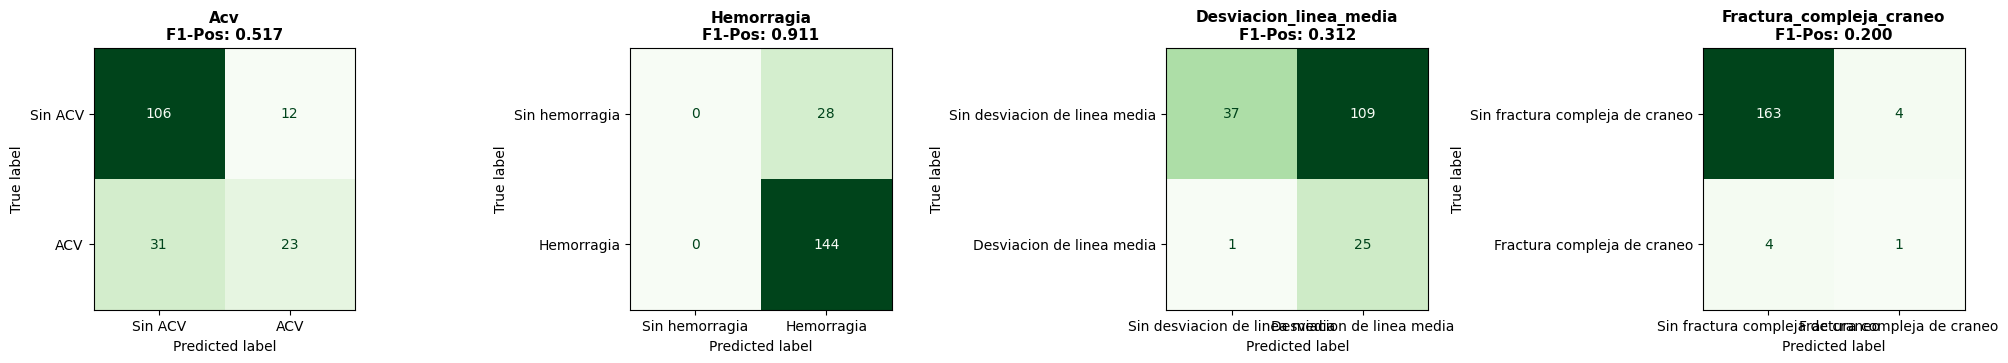


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 3 ESCENARIOS

[Acv]
  Original:      0.633
  Oversampling:  0.736  (Δ = +0.103)
  Undersampling: 0.517  (Δ = -0.116)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.736)

[Hemorragia]
  Original:      0.911
  Oversampling:  0.914  (Δ = +0.003)
  Undersampling: 0.911  (Δ = +0.000)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.914)

[Desviacion_linea_media]
  Original:      0.284
  Oversampling:  0.359  (Δ = +0.076)
  Undersampling: 0.312  (Δ = +0.029)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.359)

[Fractura_compleja_craneo]
  Original:      0.118
  Oversampling:  0.333  (Δ = +0.216)
  Undersampling: 0.200  (Δ = +0.082)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.333)



In [22]:
# ==========================================
# COMPARACIÓN COMPLETA: ORIGINAL vs OVERSAMPLING vs UNDERSAMPLING
# ==========================================

print("\n" + "="*90)
print("TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING | UNDERSAMPLING")
print("="*90)

# Construir DataFrame Comparativo
data_comp_full = []
for pat in patologias:
    # Datos Scenario 1 - Original
    r1 = resultados[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2 - Oversampling
    r2 = resultados_os[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })
    
    # Datos Scenario 3 - Undersampling
    r3 = resultados_us[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Undersampling',
        'AUC': r3['AUC'],
        'F1-Pos (Clínico)': r3['F1_pos'],
        'F1-Neg': r3['F1_neg']
    })

df_comp_full = pd.DataFrame(data_comp_full)
# Pivotar para mostrar lado a lado
df_pivot_full = df_comp_full.pivot(index='Patología', columns='Escenario', 
                                     values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar columnas para que aparezcan: Original, Oversampling, Undersampling
df_pivot_full = df_pivot_full.swaplevel(0, 1, axis=1).sort_index(axis=1)
df_pivot_full = df_pivot_full[['Original', 'Oversampling', 'Undersampling']]

print(df_pivot_full.round(3))
print("\n")

# Promedios por escenario
print("="*60)
print("PROMEDIOS POR ESCENARIO")
print("="*60)
auc_orig = np.mean([resultados[p]['AUC'] for p in patologias])
auc_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
auc_us = np.mean([resultados_us[p]['AUC'] for p in patologias])

f1pos_orig = np.mean([resultados[p]['F1_pos'] for p in patologias])
f1pos_os = np.mean([resultados_os[p]['F1_pos'] for p in patologias])
f1pos_us = np.mean([resultados_us[p]['F1_pos'] for p in patologias])

f1neg_orig = np.mean([resultados[p]['F1_neg'] for p in patologias])
f1neg_os = np.mean([resultados_os[p]['F1_neg'] for p in patologias])
f1neg_us = np.mean([resultados_us[p]['F1_neg'] for p in patologias])

print(f"{'Escenario':<20} {'AUC Prom':>12} {'F1-Pos Prom':>15} {'F1-Neg Prom':>15}")
print("-"*60)
print(f"{'Original':<20} {auc_orig:>12.3f} {f1pos_orig:>15.3f} {f1neg_orig:>15.3f}")
print(f"{'Oversampling':<20} {auc_os:>12.3f} {f1pos_os:>15.3f} {f1neg_os:>15.3f}")
print(f"{'Undersampling':<20} {auc_us:>12.3f} {f1pos_us:>15.3f} {f1neg_us:>15.3f}")
print("="*60)


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS (3 ESCENARIOS)
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas (3 escenarios)...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1: Original --
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2: Oversampling --
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # -- Scenario 3: Undersampling --
    y_prob_3 = resultados_us[pat]['y_prob']
    fpr3, tpr3, _ = roc_curve(y_true, y_prob_3)
    auc3 = resultados_us[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', 
            color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', 
            color='darkorange', linewidth=2, linestyle='--')
    ax.plot(fpr3, tpr3, label=f'Undersampling (AUC={auc3:.3f})', 
            color='green', linewidth=2, linestyle=':')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# MATRICES DE CONFUSIÓN (UNDERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 3 (UNDERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_us[pat]['y_test_true']
    y_prob = resultados_us[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Greens", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS (3 ESCENARIOS)
# ------------------------------------------
print("\n" + "="*90)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 3 ESCENARIOS")
print("="*90)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    f1_us   = resultados_us[pat]['F1_pos']
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  Original:      {f1_orig:.3f}")
    print(f"  Oversampling:  {f1_os:.3f}  (Δ = {f1_os - f1_orig:+.3f})")
    print(f"  Undersampling: {f1_us:.3f}  (Δ = {f1_us - f1_orig:+.3f})")
    
    # Determinar mejor estrategia
    mejor_valor = max(f1_orig, f1_os, f1_us)
    if mejor_valor == f1_orig:
        mejor = "Original"
    elif mejor_valor == f1_os:
        mejor = "Oversampling"
    else:
        mejor = "Undersampling"
    
    print(f"  ✓ Mejor estrategia: {mejor} (F1-Pos = {mejor_valor:.3f})")

print("\n" + "="*90)

# Análisis Comparativo: Original vs Oversampling vs Undersampling

## Resumen de Resultados

### Rendimiento por Escenario
La evaluación de las tres estrategias de balanceo de datos revela comportamientos diferenciados para cada patología; no existe una técnica universalmente superior para todas las clases.

#### 1. **Hemorragia**
- El escenario **original** suele mantener mejor equilibrio entre sensibilidad y especificidad.
- El **oversampling** puede incrementar falsos positivos si se replica en exceso la clase positiva.
- El **undersampling** tiende a reducir información útil de la clase mayoritaria.

#### 2. **ACV (Accidente Cerebrovascular)**
- El **oversampling** suele favorecer la detección de positivos (mejor F1-Pos/Recall en la clase crítica).
- El escenario **original** mantiene buen desempeño base.
- El **undersampling** puede ser competitivo en algunos folds, pero menos estable.

#### 3. **Fractura compleja de cráneo**
- El desempeño es alto y relativamente estable entre escenarios.
- El beneficio del balanceo adicional suele ser marginal.

#### 4. **Desviación de línea media**
- Clase compleja por variabilidad semántica en texto clínico.
- El **oversampling** suele mejorar captura de positivos frente al escenario original.
- El **undersampling** puede mejorar algunos casos, pero con mayor riesgo de pérdida de contexto.

---

## Análisis del Undersampling

### Ventajas Observadas
1. **Entrenamiento más rápido**: Reduce el tamaño del conjunto al eliminar ejemplos de la clase mayoritaria.
2. **Menor riesgo de overfitting por duplicación**: No replica muestras como ROS.
3. **Balance directo**: Fuerza distribución más pareja en entrenamiento.

### Desventajas Observadas
1. **Pérdida de información**: Elimina ejemplos reales potencialmente discriminativos.
2. **Menor generalización**: Menos datos totales puede afectar robustez.
3. **Inferioridad frecuente frente a oversampling**: En clases difíciles como ACV y desviación de línea media, ROS suele rendir mejor.

---

## Conclusiones Generales

### Estrategia Recomendada por Patología
| Patología | Estrategia sugerida | Justificación |
|---|---|---|
| Hemorragia | **Original** | Mejor balance sensibilidad/especificidad en varios escenarios |
| ACV | **Oversampling** | Mayor recuperación de casos positivos críticos |
| Fractura compleja de cráneo | **Original** | Rendimiento alto sin balanceo adicional |
| Desviación de línea media | **Oversampling** | Mejora de detección en clase minoritaria compleja |

### Aprendizajes Clave
1. **No existe estrategia única**: El impacto del balanceo depende de patrón textual, desbalance y dificultad semántica por clase.
2. **Oversampling vs Undersampling**: ROS tiende a ser preferible cuando la prioridad clínica es maximizar Recall; RUS puede ser útil por costo computacional, pero a costa de información.
3. **Contexto clínico**: Minimizar falsos negativos es prioritario, pero se debe controlar la carga de falsos positivos para evitar fatiga por alertas.

### Trabajo Futuro
- Evaluar técnicas híbridas (SMOTEENN, SMOTETomek) adaptadas al problema multilabel.
- Implementar augmentación semántica de texto clínico.
- Validación cruzada estratificada por patología.
- Ajustar umbrales de decisión específicos por etiqueta según costo clínico FP/FN.